In [6]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set()

# CSVを読み込む
#df = pd.read_csv('../data/0_KL/3_AllegroKukaRegrasping_CPOwoAdR_s4_KL.csv')

df = pd.read_csv('../data/0_KL/4_AllegroKukaReorientation_CPOwoAdR_s4_KL.csv')
print(len(df)) # 全部で52000になる

52000


target_envstep 15000000000
target_epoch 38146
tensor([[-1.3366e-04,  4.7200e-02,  3.1048e-02,  3.2544e-02,  4.7032e-02,
          7.0969e-02],
        [ 4.5273e-02, -1.4971e-04,  8.8431e-02,  9.4373e-02,  1.2937e-01,
          1.6196e-01],
        [ 3.0756e-02,  9.1593e-02, -1.3568e-04,  9.5070e-02,  7.1202e-02,
          1.1204e-01],
        [ 3.2961e-02,  9.9760e-02,  9.7217e-02, -1.2882e-04,  7.4371e-02,
          9.8911e-02],
        [ 4.8869e-02,  1.3987e-01,  7.4651e-02,  7.6477e-02, -1.2168e-04,
          8.4073e-02],
        [ 7.5731e-02,  1.7943e-01,  1.2090e-01,  1.0496e-01,  8.7054e-02,
         -1.0860e-04]])


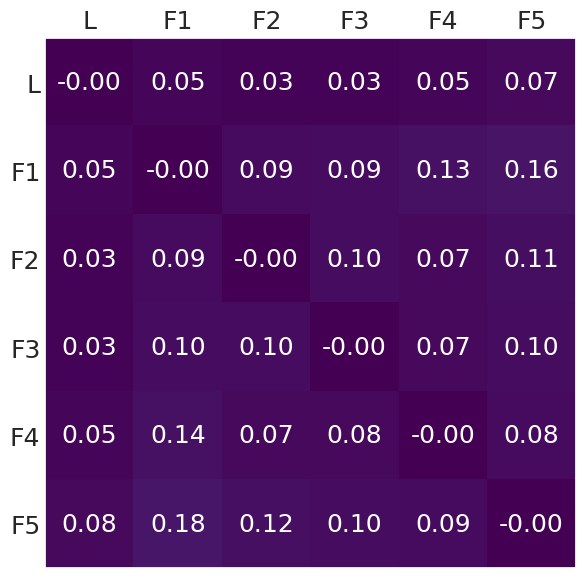

In [10]:

target_envstep = 15 * 10**9
horizon_length = 16
num_envs = 24576

target_epoch = int(target_envstep / (horizon_length * num_envs))
print("target_envstep", target_envstep)
print("target_epoch", target_epoch)

#target_epoch = 50000



row = df.iloc[target_epoch]  # 1行目だけ取り出す (Series)
# numpy配列にしてからtensor化
tensor = torch.tensor(row.values, dtype=torch.float32).view(6, 6)
tensor = torch.flip(tensor.flatten(), dims=[0]).view(6, 6)


print(tensor)


# ラベルとダミー tensor（適宜置き換えてください）
labels = ["L", "F1", "F2", "F3", "F4", "F5"]


fig, ax = plt.subplots(figsize=(6, 6))

# imshow で値を表示
im = ax.imshow(tensor.numpy(), cmap='viridis', vmin=0, vmax=3)

# 主目盛（ラベル用）
ax.set_xticks(np.arange(6))
ax.set_yticks(np.arange(6))

ax.set_xticklabels(labels, fontsize=18)
ax.set_yticklabels(labels, fontsize=18)

ax.xaxis.set_ticks_position('top')      # 目盛り（数字）を上側に
ax.xaxis.set_label_position('top')      # 軸ラベル（Xの名前など）がある場合の位置

# グリッド線をセルの境界に描画するためのマイナー目盛


#ax.grid(which='minor', color='white', linestyle='-', linewidth=0)
ax.grid(False)

# 主目盛の線は消して、すっきりさせる
ax.tick_params(which='major', length=0)

# 各セルに値を白で表示
for i in range(6):
    for j in range(6):
        val = tensor[i, j].item()
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white', fontsize=18)


# タイトル（任意）
#ax.set_title("Epoch 0 / 0")

# カラーバーとレイアウト調整
#fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
# svgに保存
fig.savefig("kl.svg", format='svg', bbox_inches='tight')